(v6_announcement)=

# PyMC v6 & PyTensor v3: ecosystem updates

:::{post} May 11, 2026
:tags: release, pytensor, numba, jax
:category: news
:author: PyMC Contributors
:::

PyMC has been under steady development since the early 2010s.
To mark the new major releases of PyMC v6 and PyTensor v3,
we want to highlight the developments across the PyMC ecosystem
(and its close cousin, the ArviZ ecosystem) that we're most excited about.

:::{image} pymc_pytensor_logos.png
:alt: PyMC and PyTensor logos
:width: 700px
:::

The short version, before we dig in:

PyMC v6 is `pip install`-able with no extra system setup. The default computational
backend is now Numba; C, JAX, and MLX remain available on demand.

NUTS sampling defaults to nutpie when it's installed. pymc-extras adds Pathfinder and
DADVI for variational inference.

The new `pymc.dims` module lets you write entire models against named dimensions.
pymc-extras covers automatic marginalization of discrete latents and a high-level
state-space API, and PyMC-BART covers Bayesian Additive Regression Trees.

`pytensor.wrap_jax` brings arbitrary JAX functions into PyMC models, and PyMC's
growing automatic logp derivation lets you build new distributions from existing ones.

ArviZ has reached 1.0 with a redesigned plotting library and `xarray.DataTree`-backed
inference data. Kulprit brings projective variable selection, and PreliZ continues to
grow as the prior-elicitation companion.

## Performance

PyMC hasn't always been a breeze to use. It's written in Python, and its backend
(Theano, and its successor PyTensor) had accrued some weight over the years.

A lot of effort was devoted to speeding up all stages of work:
from import times, to model compilation and sampling runtime.

### Numba is the new default backend

Historically, PyMC compiled model functions to **C**, with some support for CUDA. In v6 we
switch the default linker to **Numba**. For most CPU workloads Numba matches or beats C,
while being far easier to maintain and extend.
It also unlocks a few things the old C path always struggled with:

- **Native advanced indexing** — the hierarchical-modelling staple that the C
  backend has always struggled with. Numba supports (almost) all cases natively
  and is noticeably faster.
- **LAPACK bindings for linear algebra** — `cholesky`, `solve`, `eigh`, and
  friends aren't bottlenecked by Python.
- **Fast `scan`** — historically the slowest piece of the C backend, now far
  closer to looping in a low-level language (with autodiff). A big win for
  time-series and other recursive-structure models.
- **Native sparse support** — useful for spatial models (ICAR), state-space
  models, and INLA-style inference.


A knock-on win: **PyMC is finally `pip install`-safe.** The old C backend needed a system
BLAS installation *and* a C compiler, both beyond pip's reach. The first-time experience on a
clean machine used to greet you with a prominent "PyTensor could not link to a BLAS
installation" warning and degraded performance (or worse if a compiler couldn't be detected).
Conda/mamba was the only reliable path.

### One-liner backend selection with `backend=`

You can pass `backend=` to **every** sampling and inference entry point
(`pm.sample`, `pm.sample_posterior_predictive`, `pm.fit`, and so on).

Accepted values include `"numba"`, `"c"`, and `"jax"`.

The default backend of `pm.sample` is `"numba"`. You only need to pass it explicitly
when picking something else.

**Availability:** Numba and C come with PyMC, though C needs both a compiler
and a working BLAS installation at runtime to be usable. JAX has to be installed separately.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pymc as pm

In [2]:
rng = np.random.default_rng(0)
y_obs = rng.normal(1.0, 0.5, size=50)

with pm.Model() as simple_model:
    mu = pm.Normal("mu")
    sigma = pm.HalfNormal("sigma")
    pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)

In [3]:
with simple_model:
    idata_numba = pm.sample(backend="numba", quiet=True)
    idata_jax = pm.sample(backend="jax", quiet=True)
    idata_c = pm.sample(backend="c", quiet=True)

All should arrive at the same place, if not at the same time.

In [4]:
pd.concat([
    pm.stats.summary(idata_numba, var_names=["mu"], kind="stats").rename({"mu": "mu (numba)"}),
    pm.stats.summary(idata_jax, var_names=["mu"], kind="stats").rename({"mu": "mu (jax)"}),
    pm.stats.summary(idata_c, var_names=["mu"], kind="stats").rename({"mu": "mu (c)"}),
])

,mean,sd,eti89_lb,eti89_ub
mu (numba),1.1,0.068,0.95,1.2
mu (jax),1.1,0.066,0.95,1.2
mu (c),1.1,0.068,0.95,1.2


## Inference

### nutpie: the new default NUTS sampler

PyMC has historically latched onto Stan's implementation of NUTS,
borrowing its code almost line-by-line.
It was time to contribute something back, and that something is
[**nutpie**](https://pymc-devs.github.io/nutpie/).

You can easily install pymc and nutpie together as:

```bash
pip install pymc[nutpie]
```

Once installed, nutpie becomes the **default** NUTS in PyMC.

Three things set it apart from what we had before:

- **Faster adaptation.** nutpie often gets away with ~400 tuning draws where the old default
  conservatively used 1000, and after tuning it takes fewer leapfrog steps per draw, with no
  loss of accuracy. For the details, see [Seyboldt, Carlson, & Carpenter (2026)](https://arxiv.org/abs/2603.18845).
- **Low-rank mass-matrix adaptation.** For posteriors with strongly correlated parameters, the
  diagonal mass matrix used by most HMC implementations is a poor fit. nutpie offers a low-rank
  extension of the diagonal that can dramatically reduce the number of gradient evaluations per
  effective draw on funnels, regressions with collinear predictors, and similar shapes.
- **Native integration with Numba and JAX backends.** No Python overhead.

An experimental **normalizing-flow adaptation** is also available for really difficult
posteriors; see the [nutpie docs](https://pymc-devs.github.io/nutpie/nf-adapt.html).

To be sure not to miss the train, set `nuts_sampler="nutpie"` explicitly.

In [5]:
with simple_model:
    idata_nutpie = pm.sample(nuts_sampler="nutpie")

NUTS[nutpie]: [mu, sigma]


Output()

In [6]:
pm.stats.summary(idata_nutpie)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,1.06,0.07,0.95,1.2,3927,2815,1.00,0.0011,0.0008
sigma,0.472,0.05,0.4,0.56,3721,2527,1.00,0.00083,0.00065


A classic nasty posterior: a simple linear regression where the covariate sits far from zero,
making the intercept and slope strongly anti-correlated in the likelihood.

In [7]:
rng_corr = np.random.default_rng(1)
N = 200
x_far = rng_corr.normal(1000.0, 1.0, size=N)
y_far = 2.0 + 3.0 * x_far + rng_corr.normal(0.0, 1.0, size=N)

with pm.Model() as regression_far:
    a = pm.Normal("a", 0.0, 10)
    b = pm.Normal("b", 0.0, 10.0)
    sigma = pm.HalfNormal("sigma", 1.0)
    pm.Normal("y", mu=a + b * x_far, sigma=sigma, observed=y_far)

In [8]:
with regression_far:
    idata_diag = pm.sample(nuts={"adaptation": "diag"}, quiet=True)

pm.stats.summary(idata_diag, var_names=["a", "b"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,-0.4,10.2,-16,17,425,298,1.01,0.49,0.33
b,3.0023,0.0102,3,3,425,297,1.01,0.00049,0.00033


The low rank adaptation fares much better than the default diagonal mass matrix adaptation.

In [9]:
with regression_far:
    idata_lr = pm.sample(nuts={"adaptation": "low_rank"}, quiet=True)

pm.stats.summary(idata_lr, var_names=["a", "b"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,-0.6,10.1,-17,16,6072,3086,1.00,0.13,0.09
b,3.0025,0.0101,3,3,6076,3090,1.00,0.00013,9e-05


### Variational inference (pymc-extras): Pathfinder & DADVI

pymc-extras includes two modern Variational Inference solutions.

**Pathfinder** Pathfinder is a parallel quasi-Newton variational approximation:
it runs L-BFGS from multiple starting points and combines the resulting trajectories using Pareto-smoothed importance sampling.
It's fast, parallelizable, and useful both as a NUTS warm-start and as a standalone approximation. See [Zhang et al. (2022)](https://arxiv.org/abs/2108.03782).

In [10]:
from pymc_extras import fit_pathfinder

with simple_model:
    idata_pf = fit_pathfinder(display_summary=False)

Output()

**DADVI** — *Deterministic* ADVI.
Instead of stochastic optimization of the ELBO, it draws a fixed Monte Carlo sample upfront
and hands the resulting deterministic objective to a second-order optimizer.
Three things fall out of this: convergence is unambiguous (no more "is the ELBO done bouncing around?"),
off-the-shelf optimizers like L-BFGS work directly, and DADVI supports linear-response covariance corrections
that fix the variance underestimation that mean-field ADVI is famous for. See [Giordano, Ingram & Broderick (2024)](https://jmlr.org/papers/volume25/23-1015/23-1015.pdf).

In [11]:
from pymc_extras.inference import fit_dadvi

with simple_model:
    idata_dadvi = fit_dadvi()

Output()

In [12]:
pd.concat([
    pm.stats.summary(idata_pf, var_names=["mu"], kind="stats").rename({"mu": "mu (pathfinder)"}),
    pm.stats.summary(idata_dadvi, var_names=["mu"], kind="stats").rename({"mu": "mu (dadvi)"}),
])

,mean,sd,eti89_lb,eti89_ub
mu (pathfinder),1.1,0.065,0.95,1.2
mu (dadvi),1.1,0.073,0.94,1.2


## Modelling

A brief tour of four modelling additions: named-dimension models with `pymc.dims`,
automatic marginalization of discrete latents, the state-space API, and PyMC-BART.

### Named dims with `pymc.dims`

PyMC's `dims=` argument has existed since 2020 to label the axes of model variables.
The new `pymc.dims` module (backed by PyTensor's XTensor) lets you write **entire models**
against named dimensions, with automatic broadcasting, no more `[:, None, :]` gymnastics,
and no more guessing which axis is which.

A compact example (adapted from the [pymc.dims core
notebook](https://www.pymc.io/projects/docs/en/latest/learn/core_notebooks/dims_module.html)).

In [13]:
import pymc.dims as pmd

coords = {
    "participant": range(5),
    "trial": range(20),
    "item": range(3),
}
observed_response_np = np.ones((5, 20), dtype=int)

with pm.Model(coords=coords) as dmodel:
    observed_response = pmd.Data(
        "observed_response",
        observed_response_np,
        dims=("participant", "trial"),
    )

    participant_preference = pmd.ZeroSumNormal(
        "participant_preference",
        core_dims="item",
        dims=("participant", "item"),
    )
    time_effects = pmd.Normal("time_effects", dims=("item", "trial"))

    trial_preference = pmd.Deterministic(
        "trial_preference",
        participant_preference + time_effects,
    )

    response = pmd.Categorical(
        "response",
        p=pmd.math.softmax(trial_preference, dim="item"),
        core_dims="item",
        observed=observed_response,
    )

Note the absence of `None`-indexing to create new axes, right-aligning conventions or numerical `axis` arguments.

Also new: the `Model.table()` method renders a summary of every variable together
with its expression and dimensions, a much more compact view than the good old `Model.to_graphviz()`.

In [14]:
dmodel.table()

                 Variable  Expression                               Dimensions                           
─────────────────────────────────────────────────────────────────────────────────────────────────────────
      observed_response =  Data                                     participant[5] × trial[20]           
                                                                                                         
 participant_preference ~  ZeroSumNormal(<constant>, <constant>)    participant[5] × item[3]             
           time_effects ~  Normal(0, 1)                             item[3] × trial[20]                  
                                                                    Parameter count = 75                 
                                                                                                         
       trial_preference =  f(time_effects, participant_preference)  participant[5] × item[3] × trial[20] 
                                                                                                         
               response ~  Categorical(f(trial_preference))         participant[5] × trial[20]

### Automatic marginalization (pymc-extras)

Discrete latent variables are a pain to sample with gradient-based MCMC.
Traditionally you'd have to sum them out by hand and rewrite your model as a marginal likelihood.
`pymc_extras.marginalize` automates that process.

In [15]:
from pymc_extras import marginalize, recover_marginals

rng_mix = np.random.default_rng(2)
y_mix = rng_mix.normal(loc=np.tile([-2, 2], reps=50))
mix_coords = {"component": ["left", "right"], "obs": range(len(y_mix))}

with pm.Model(coords=mix_coords) as mix_model:
    w = pm.Dirichlet("w", a=np.ones(2))
    mu = pm.Normal("mu", mu=[-3.0, 3.0], dims="component")
    sigma = pm.HalfNormal("sigma", dims="component")
    z = pm.Categorical("z", p=w, dims="obs")
    pm.Normal("y", mu=mu[z], sigma=sigma[z], observed=y_mix, dims="obs")

In [16]:
with marginalize(mix_model, ["z"]) as marginal_model:
    idata_mix = pm.sample(quiet=True)

pm.stats.summary(idata_mix, var_names=["w", "mu"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
w[0],0.497,0.057,0.41,0.59,3053,2868,1.00,0.001,0.00072
w[1],0.503,0.057,0.41,0.59,3053,2868,1.00,0.001,0.00072
mu[left],-1.908,0.166,-2.2,-1.6,2386,1986,1.00,0.0035,0.0031
mu[right],1.88,0.176,1.6,2.1,2602,2207,1.00,0.0035,0.0029


After sampling the marginalized model, you can still **recover draws for the discrete
latents** with `recover_marginals`. The component assignments for each observation come back
as proper posterior estimates.

In [17]:
with marginal_model:
    idata_mix = recover_marginals(idata_mix)

In [18]:
pm.stats.summary(idata_mix.isel(obs=slice(None, 6)), var_names=["z"], kind="stats")[["mean", "sd"]]

,mean,sd
z[0],0.003,0.055
z[1],0.99,0.077
z[2],0.0013,0.035
z[3],0.22,0.41
z[4],0.38,0.49
z[5],1,0.016


### Statespace (pymc-extras)

`pymc_extras.statespace` offers Bayesian statespace models with an increasingly rich high-level API:
`BayesianETS`, `BayesianSARIMAX`, `BayesianVARMAX`, plus a `structural` package for
composing custom models out of level, trend, seasonal, and cyclical components.

Here we fit a Holt–Winters ETS model (level + trend + additive quarterly seasonality) to a
synthetic series generated from the same innovation-form process. Missing entries are
imputed by the Kalman filter, and an 8-quarter forecast comes for free.

In [19]:
from pymc_extras.statespace.models import BayesianETS

rng = np.random.default_rng(3)
T, m = 60, 4
sigma_obs_true = 0.8
level, trend = 10.0, 0.05
seasonal = 2.0 * np.sin(2 * np.pi * np.arange(m) / m)
y_ts = np.array([
    level + trend * i + seasonal[i % m] + rng.normal(0, sigma_obs_true)
    for i in range(T)
])

dates = pd.date_range("2000-Q1", periods=T, freq="QS")
y_df = pd.DataFrame({"y": y_ts}, index=dates)
y_df.loc["2007-Q1":"2008-Q4", "y"] = np.nan  # Kalman filter will impute

ets = BayesianETS(
    order=("A", "A", "A"),
    endog_names=["y"],
    seasonal_periods=m,
    measurement_error=True,
    stationary_initialization=True,
)

                       Model Requirements                       
                                                                
  Variable           Shape   Constraints            Dimensions  
 ────────────────────────────────────────────────────────────── 
  initial_level      ()                                   None  
  initial_trend      ()                                   None  
  initial_seasonal   (4,)                    ('seasonal_lag',)  
  alpha              ()      0 < alpha < 1                None  
  beta               ()      0 < beta < 1                 None  
  gamma              ()      0 < gamma < 1                None  
  sigma_state        ()      Positive                     None  
  sigma_obs          ()      Positive                     None  
                                                                
 These parameters should be assigned priors inside a PyMC model 
    block before calling the build_statespace_graph method.     

In [20]:
with pm.Model(coords=ets.coords) as ets_model:
    pm.Normal("initial_level", mu=10, sigma=5)
    pm.Normal("initial_trend", mu=0, sigma=1)
    pm.ZeroSumNormal("initial_seasonal", sigma=2, dims="seasonal_lag")

    pm.Beta("alpha", 1, 1)
    pm.Beta("beta", 1, 1)
    pm.Beta("gamma", 1, 1)

    pm.Deterministic("sigma_state", pm.math.constant(np.array(0.0)))
    pm.HalfNormal("sigma_obs", 1)

    ets.build_statespace_graph(y_df)

    idata_ets = pm.sample(backend="jax", progressbar="combined")

NUTS[nutpie]: [initial_level, initial_trend, initial_seasonal, alpha, beta, gamma, sigma_obs]


Output()

An 8-quarter forecast falls out of `ets.forecast`, and `ets.sample_conditional_posterior`
fills in the imputed gap inside the training window. Structural decomposition and scenario
analyses are similarly built in.

In [21]:
smoothed = ets.sample_conditional_posterior(idata_ets, progressbar=False)
forecast = ets.forecast(idata_ets, start=y_df.index[-1], periods=8, progressbar=False)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]
Sampling: [forecast_combined]


Plot the smoothed in-sample fit (orange) and the 8-quarter forecast (blue),
with 89% credible bands.

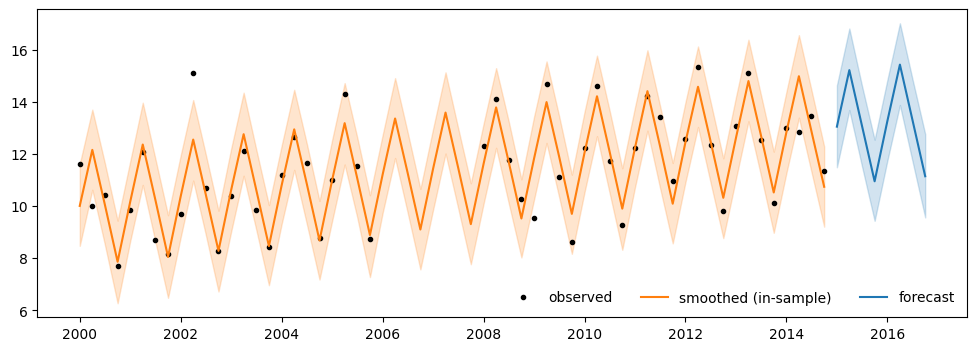

In [22]:
sm = smoothed["smoothed_posterior_observed"].sel(observed_state="y")
fc = forecast["forecast_observed"].sel(observed_state="y")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_df.index, y_df["y"], "k.", label="observed")
ax.plot(y_df.index, sm.mean(("chain", "draw")), "C1", label="smoothed (in-sample)")
ax.fill_between(
    y_df.index,
    sm.quantile(0.055, ("chain", "draw")),
    sm.quantile(0.945, ("chain", "draw")),
    color="C1",
    alpha=0.2,
)
ax.plot(fc.time, fc.mean(("chain", "draw")), "C0", label="forecast")
ax.fill_between(
    fc.time,
    fc.quantile(0.055, ("chain", "draw")),
    fc.quantile(0.945, ("chain", "draw")),
    color="C0",
    alpha=0.2,
)
ax.legend(loc="lower right", ncol=3, frameon=False);

### PyMC-BART

[PyMC-BART](https://www.pymc.io/projects/bart/) brings **Bayesian Additive Regression
Trees** to PyMC: a non-parametric prior on functions, expressed as an ensemble of
decision trees.

Newer versions add plotting utilities (partial dependence, variable importance)
and direct variable-importance integration with **Kulprit** (see next section).
BART can then guide downstream variable selection on a parametric follow-up model.
An experimental Rust tree sampler is also available.

In [23]:
import pandas as pd
import pymc_bart as pmb

rng_bart = np.random.default_rng(4)
n = 200
X_bart = pd.DataFrame(
    rng_bart.normal(size=(n, 4)),
    columns=["x0", "x1", "x2", "x3"],
)
# Only X_0 and X_2 actually drive the response
y_bart = np.sin(1.5 * X_bart["x0"]) + 0.7 * X_bart["x2"] ** 2 + rng_bart.normal(0, 0.3, n)

with pm.Model() as bart_model:
    mu = pmb.BART("mu", X_bart, y_bart, m=50)
    sigma = pm.HalfNormal("sigma", 1.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y_bart)
    idata_bart = pm.sample(progressbar="combined")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 64 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


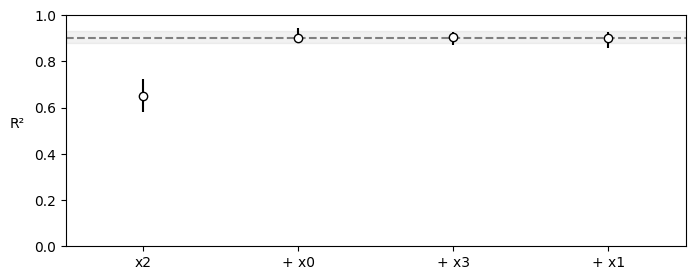

In [24]:
# Variable importance — columns 0 and 2 should account for all cumulative R2.
vi = pmb.compute_variable_importance(idata_bart, bartrv=mu, X=X_bart)
pmb.plot_variable_importance(vi);

## More building blocks

Two tools for when PyMC's built-ins don't quite fit: `wrap_jax` plugs arbitrary
JAX functions into a model, and automatic logp derivation builds new
distributions from existing ones.

### Drop-in JAX with `pytensor.wrap_jax`

`pytensor.wrap_jax` lets you call any JAX-jittable function directly inside a PyMC model.
That means the whole JAX ecosystem (Equinox neural networks, Diffrax ODE solvers, Optax optimizers)
composes directly with your priors and likelihoods. Train a Bayesian neural network.
Put a prior on the parameters of an ODE. Mix and match.

In [25]:
import jax.numpy as jnp
from pytensor import wrap_jax

@wrap_jax
def forward(x, a, b):
    return jnp.tanh(a * x + b)

rng = np.random.default_rng(5)
x_wj = rng.normal(size=100)
y_wj = np.tanh(0.8 * x_wj + 0.1) + rng.normal(0, 0.1, size=100)

with pm.Model() as wrap_jax_model:
    a = pm.Normal("a")
    b = pm.Normal("b")
    mu_wj = forward(x_wj, a, b)
    pm.Normal("y", mu=mu_wj, observed=y_wj)

    idata_wj = pm.sample(backend="jax", progressbar="combined")

pm.stats.summary(idata_wj)

NUTS[nutpie]: [a, b]


Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b,0.128,0.148,-0.1,0.37,2579,2154,1.00,0.003,0.0023
a,0.88,0.27,0.52,1.3,2000,1803,1.00,0.0066,0.008


Sampling still runs through nutpie. `backend="jax"` just tells PyMC to compile the model through the JAX path,
so the wrapped function stays native end-to-end.

### Automatic probability & `CustomDist`

Most PPLs let you define models by chaining random variables and derive the log-density automatically.
What's less known is that PyMC can also derive log-densities for transformations of existing distributions:
exponentiating, taking maxima, slicing. All without writing the math yourself.

Here we build a log-Student-T as exp of a Student-T, and ask PyMC for its log-density at 0.5

In [26]:
log_student_t = pm.math.exp(pm.StudentT.dist(nu=4, mu=0, sigma=1))

print(f"logp(LogStudentT, 0.5): {pm.logp(log_student_t, 0.5).eval():.4f}")

logp(LogStudentT, 0.5): -0.5713


The way to wire this into a model is with `pm.CustomDist`, which turns any `dist`-building
function into a proper PyMC distribution:

In [27]:
def log_student_t_dist(nu, mu, sigma, size):
    return pm.math.exp(pm.StudentT.dist(nu=nu, mu=mu, sigma=sigma, size=size))


with pm.Model() as m:
    mu = pm.Normal("mu")
    sigma = pm.HalfNormal("sigma")
    y = pm.CustomDist("y", 4.0, mu, sigma, dist=log_student_t_dist, observed=0.5)

print(f"logp(y): {m.point_logps(round_vals=4)['y']}")

np.float64(-0.5713)

## Bayesian workflow

### ArviZ 1.0

PyMC v6 is compatible with the new **ArviZ 1.0**. Most of the changes are
invisible, the object returned by `pm.sample` still resembles the good old
`InferenceData`, and the usual `az.plot_*` and `az.summary` calls keep working.

A few changes worth knowing:

- **InferenceData → xarray.DataTree.** Arbitrary nesting is now allowed and any
  xarray-supported I/O format works. Existing netCDF/Zarr files keep loading.
- **New plotting library.** arviz-plots supports three backends (Matplotlib,
  Bokeh, Plotly) and returns a `PlotCollection` built on grammar-of-graphics
  ideas, with cleaner faceting and aesthetic mappings.
- **New plots.** The suite of built-in plots has grown notably around
  posterior-predictive checks. Browse them in the
  [example gallery](https://python.arviz.org/projects/plots/en/latest/gallery/index.html).
- **New default credible interval** has changed from 0.94 to 0.89, to remind
  everyone that no single number can rule us all. The default interval kind is
  now equal-tailed (`"eti"`) rather than highest-density (`"hdi"`), and WAIC has
  been removed in favor of PSIS-LOO-CV.

Oh and `plot_trace` is now `plot_trace_dist`...

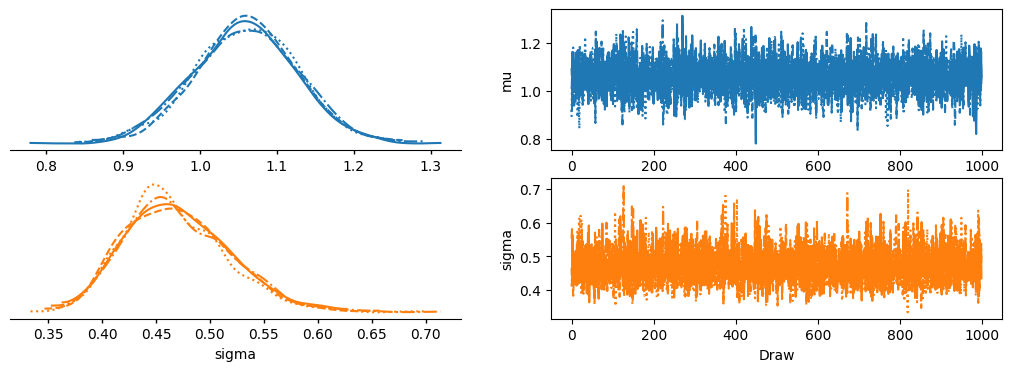

In [28]:
pm.plots.plot_trace_dist(idata_numba);

... although you may want to try `plot_rank_dist` instead.

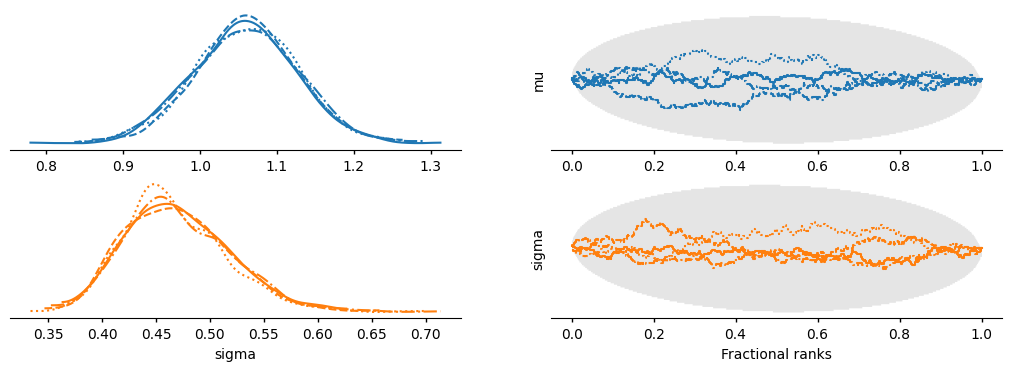

In [29]:
pm.plots.plot_rank_dist(idata_numba);

### PreliZ — prior elicitation

[PreliZ](https://preliz.readthedocs.io/) helps with one of the trickiest parts of the Bayesian workflow: prior choice.

There's a new [Distributions Gallery](https://preliz.readthedocs.io/en/latest/gallery/gallery.html) to help get familiar with every family PreliZ supports.

Recent PreliZ work integrates PyMC distributions and pymc-extras `Prior` objects
directly: `maxent`, matching, and plotting all accept them. `from_pymc` /
`from_prior` convert them explicitly.

`maxent` is one of the package's most useful tools: it picks the maximum-entropy distribution matching a target probability interval, a principled way to translate vague prior knowledge into a concrete prior. It also accepts any summary statistic (mean, variance, mode, …) as a fixed constraint:

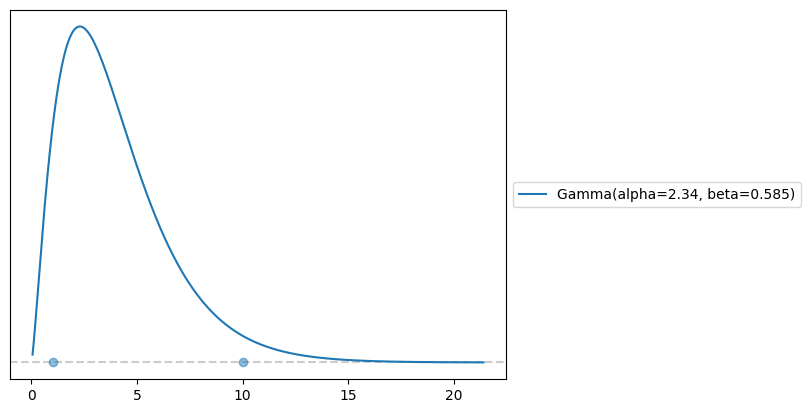

In [30]:
import preliz as pz

# "Find a Gamma with mass 0.9 between 1 and 10 — and pin the mean to 4."
(prior, _fig) = pz.maxent(pz.Gamma(), lower=1, upper=10, mass=0.90, fixed_stat=("mean", 4))

In [31]:
with pm.Model() as m:
    x = prior.to_pymc("x")
    idata = pm.sample(quiet=True)
pm.stats.summary(idata)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
x,4,2.6,0.87,8.9,1286,1298,1.00,0.065,0.064


### Kulprit — variable selection

[Kulprit](https://kulprit.readthedocs.io/) tackles a problem that shows up in almost
every real study: you fit your best model with all the predictors you measured, but
for interpretation or deployment you want a smaller one. Which predictors do you
actually need?

Given a **Bambi** model with all candidates, Kulprit projects the full posterior onto
smaller submodels using [projective predictive inference](https://kulprit.readthedocs.io/en/latest/examples/Overview.html).
The projection keeps the uncertainty calibration of the original, and scales better
than LOO-based comparison when the candidate count is large.

In [32]:
import bambi
import kulprit

# 4 candidate predictors; only x0 and x2 actually drive the response.
rng_k = np.random.default_rng(6)
n = 200
df_k = pd.DataFrame(rng_k.normal(size=(n, 4)), columns=["x0", "x1", "x2", "x3"])
df_k["y"] = 0.5 + 1.5 * df_k["x0"] + 0.8 * df_k["x2"] + rng_k.normal(0, 0.3, n)

full_model = bambi.Model("y ~ x0 + x1 + x2 + x3", df_k)
idata_full = full_model.fit(quiet=True)
pm.compute_log_likelihood(idata_full, model=full_model.backend.model, progressbar=False)

ppi = kulprit.ProjectionPredictive(full_model, idata_full)
ppi.project()
print(f"Selected: {ppi.select()}")

Selected: ['Intercept', 'x0', 'x2']


## Thanks

Almost none of what we covered above came from a single person. Since the v5 and v2
releases of PyMC and PyTensor, each project has seen contributions from around 150
different individuals: bug fixes, documentation, new features, entire new packages.
The surrounding libraries (ArviZ, nutpie, PyMC-BART, pymc-extras, PreliZ, Kulprit,
Bambi) are maintained by a similarly broad and overlapping community.

Whether you'd like to contribute or just try things out, the [PyMC Discourse](https://discourse.pymc.io/)
is the easiest place to ask questions, share feedback, and discuss ideas. The GitHub repos
are open for bug reports and pull requests. See you there.

:::{image} star_rating.png
:alt: star rating
:width: 700px
:::
